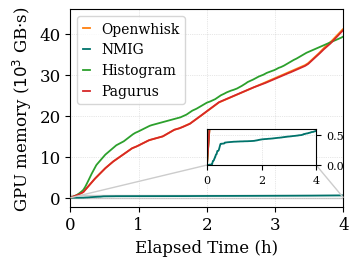

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib as mpl

first_invocation_bursty = 0
mpl.rcParams['font.family'] = 'DejaVu Serif'
# normal dataset
# filename = "graphs_images/new_gpu_mem_normal.jpg"
# experiments = [
#     {"id": "exp_20250626_205804", "name": "Openwhisk"},
#     {"id": "exp_20250627_042542", "name": "NMIG"},
#     {"id": "exp_20250626_155721", "name": "Histogram"},
#     {"id": "exp_20250626_113035", "name": "Pagurus"},
# ]

# similar dataset
filename = "graphs_images/new_gpu_mem_similar.jpg"
experiments = [
    {"id": "exp_20260602_170520", "name": "Openwhisk"},
    {"id": "exp_20250625_113106", "name": "NMIG"},
    {"id": "exp_20250625_211541", "name": "Histogram"},
    {"id": "exp_20250626_050332", "name": "Pagurus"},
]

color_map = {
    "NMIG": "#00736b",
    "Openwhisk": "#ff7f0e",
    "Histogram": "#2ca02c",
    "Pagurus": "#d62728",
}

MB_TO_GB = 1024.0
aligned_results = {}

for exp in experiments:
    fn = pd.read_csv(f"../results/{exp['id']}/results_updated.csv")
    df = pd.read_csv(f"../results/{exp['id']}/gpu_usage.csv")

    first_fn_timestamp_ms = fn['timestamp'].iloc[0]
    initial_time_ms = first_fn_timestamp_ms + first_invocation_bursty * 1000

    df['datetime'] = pd.to_datetime(df['Timestamp'], unit='ms')
    df['second_level_datetime'] = df['datetime'].dt.floor('s')

    df_avg = (
        df.groupby(['ContainerID', 'second_level_datetime'])['GPU_Memory_MB']
          .mean()
          .reset_index()
          .rename(columns={'GPU_Memory_MB': 'Avg_GPU_Memory_MB'})
    )
    df_avg['gb'] = df_avg['Avg_GPU_Memory_MB'] / MB_TO_GB

    mem_per_second = (
        df_avg.groupby('second_level_datetime')['gb']
              .sum()
              .reset_index(name='gb_per_second')
    )

    initial_datetime = pd.to_datetime(initial_time_ms, unit='ms')
    mem_per_second['relative_seconds'] = (
        (mem_per_second['second_level_datetime'] - initial_datetime)
        .dt.total_seconds()
        .astype(int)
    )

    mem_per_second = mem_per_second[mem_per_second['relative_seconds'] >= 0].reset_index(drop=True)

    max_sec = mem_per_second['relative_seconds'].max()
    full_sec = pd.DataFrame({'relative_seconds': range(max_sec + 1)})
    mem_per_second = full_sec.merge(mem_per_second, on='relative_seconds', how='left')
    mem_per_second['gb_per_second'] = mem_per_second['gb_per_second'].fillna(0)

    mem_per_second['cumulative_gbs'] = mem_per_second['gb_per_second'].cumsum()
    mem_per_second['relative_hours'] = mem_per_second['relative_seconds'] / 3600

    # pad to full 4 hours
    t_target = 4 * 3600
    if mem_per_second['relative_seconds'].max() < t_target:
        last_val = mem_per_second['cumulative_gbs'].iloc[-1]
        extra = pd.DataFrame({
            'relative_seconds': [t_target],
            'gb_per_second': [0],
            'cumulative_gbs': [last_val],
            'relative_hours': [t_target / 3600],
        })
        mem_per_second = pd.concat([mem_per_second, extra], ignore_index=True)

    aligned_results[exp['name']] = mem_per_second

# ---------- Plotting ----------
plt.figure(figsize=(3.5, 2.5))
ax = plt.gca()

for name, df in aligned_results.items():
    ax.plot(
        df['relative_hours'],
        df['cumulative_gbs'] / 1000.0,          # plot in 10^3 GB·s
        label=name,
        linewidth=1.3,
        linestyle='-',
        color=color_map.get(name, 'black'),
        marker='',
    )

ax.set_xlabel('Elapsed Time (h)', fontsize=12)
ax.set_ylabel(r'GPU memory ($10^3$ GB$\cdot$s)', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(fontsize=10, handlelength=0.5)
ax.grid(linestyle=':', linewidth=0.5, alpha=0.6)
ax.set_xlim(0, 4)

# inset zoom for NMIG (small nonzero range)
axins = inset_axes(ax, width="80%", height="30%",
                   bbox_to_anchor=(0.45, 0.001, 0.5, 0.6),
                   bbox_transform=ax.transAxes,
                   loc='center')

for name, df in aligned_results.items():
    axins.plot(
        df['relative_hours'],
        df['cumulative_gbs'] / 1000.0,
        label=name,
        linewidth=1.3,
        linestyle='-',
        color=color_map.get(name, 'black'),
        marker='',
    )

axins.set_xlim(0, 4)
axins.set_ylim(0, 0.6)                 # 600 GB·s = 0.6 in 10^3 units (bursty)
axins.grid(linestyle=':', linewidth=0.5, alpha=0.6)
axins.tick_params(labelsize=8)
axins.yaxis.set_label_position("right")  # move inset ticks to the right
axins.yaxis.tick_right()

mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec="0.8")

# explicit margins so the y-label is not clipped
plt.subplots_adjust(left=0.19, bottom=0.18, right=0.97, top=0.97)


plt.savefig(filename, dpi=300, bbox_inches='tight', pad_inches=0.02)
plt.show()

In [14]:
import pandas as pd
import numpy as np

# ---- point this at whichever dataset you're processing ----
first_invocation_time = 0
# normal dataset
# filename = "graphs_images/new_gpu_mem_normal.jpg"
# experiments = [
#     {"id": "exp_20250626_205804", "name": "Openwhisk"},
#     {"id": "exp_20250627_042542", "name": "NMIG"},
#     {"id": "exp_20250626_155721", "name": "Histogram"},
#     {"id": "exp_20250626_113035", "name": "Pagurus"},
# ]

# similar dataset
# filename = "graphs_images/new_gpu_mem_similar.jpg"
# experiments = [
#     {"id": "exp_20250625_162425", "name": "Openwhisk"},
#     {"id": "exp_20250625_113106", "name": "NMIG"},
#     {"id": "exp_20250625_211541", "name": "Histogram"},
#     {"id": "exp_20250626_050332", "name": "Pagurus"},
# ]

#Bursty
experiments = [
    {"id": "exp_20250625_014444", "name": "Openwhisk"},
    {"id": "exp_20250625_071954", "name": "NMIG"},
    {"id": "exp_20250624_210136", "name": "Histogram"},
    {"id": "exp_20250624_165438", "name": "Pagurus"},
]



COST_PER_MB_PER_SECOND = 0.00001
T_TARGET = 4 * 3600

summary = {}

for exp in experiments:
    fn = pd.read_csv(f"../results/{exp['id']}/results_updated.csv")
    df = pd.read_csv(f"../results/{exp['id']}/gpu_usage.csv")

    initial_time_ms = fn['timestamp'].iloc[0] + first_invocation_time * 1000
    df['second_level_datetime'] = pd.to_datetime(df['Timestamp'], unit='ms').dt.floor('s')

    # avg resident GPU memory per container per second, then summed across containers
    df_avg = (df.groupby(['ContainerID', 'second_level_datetime'])['GPU_Memory_MB']
                .mean().reset_index())
    mem_per_second = (df_avg.groupby('second_level_datetime')['GPU_Memory_MB']
                            .sum().reset_index(name='total_mem_mb'))

    initial_dt = pd.to_datetime(initial_time_ms, unit='ms')
    mem_per_second['rel_s'] = ((mem_per_second['second_level_datetime'] - initial_dt)
                               .dt.total_seconds().astype(int))
    mem_per_second = mem_per_second[mem_per_second['rel_s'] >= 0].reset_index(drop=True)

    # fill every second to T_TARGET so all runs share one horizon
    full = pd.DataFrame({'rel_s': range(T_TARGET + 1)})
    m = full.merge(mem_per_second[['rel_s', 'total_mem_mb']], on='rel_s', how='left')
    m['total_mem_mb'] = m['total_mem_mb'].fillna(0)

    # --- the three metrics, all from the same series ---
    gpu_mem_seconds_mb_s = m['total_mem_mb'].sum()          # MB·s
    gpu_mem_seconds_gb_s = gpu_mem_seconds_mb_s / 1024.0    # GB·s  (resource metric)
    total_cost = gpu_mem_seconds_mb_s * COST_PER_MB_PER_SECOND  # $ (your existing metric)
    mean_resident_mb = m['total_mem_mb'].mean()             # avg held memory
    peak_resident_mb = m['total_mem_mb'].max()              # peak held memory
    # idle-memory share: fraction of GPU-mem-seconds while no inference is active
    # (only meaningful if you can mark active seconds; see note below)

    summary[exp['name']] = {
        'GPU-mem-seconds (GB·s)': gpu_mem_seconds_gb_s,
        'GPU cost ($)': total_cost,
        'Mean resident GPU mem (MB)': mean_resident_mb,
        'Peak resident GPU mem (MB)': peak_resident_mb,
    }

summary_df = pd.DataFrame(summary).T
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
print(summary_df, '\n')

# reduction of NMIG vs each baseline, per metric — paste these into the paper
nmig = summary['NMIG']
for metric in summary_df.columns:
    print(f'\n{metric}:')
    for name in summary:
        if name == 'NMIG':
            continue
        base = summary[name][metric]
        red = (base - nmig[metric]) / base * 100 if base else float('nan')
        print(f'  vs {name:10s}: {red:6.2f}% reduction  (NMIG {nmig[metric]:,.3f} vs {base:,.3f})')

           GPU-mem-seconds (GB·s)  GPU cost ($)  Mean resident GPU mem (MB)  \
Openwhisk              98,869.659     1,012.425                   7,030.243   
NMIG                      529.870         5.426                      37.677   
Histogram              95,494.407       977.863                   6,790.242   
Pagurus               101,124.114     1,035.511                   7,190.549   

           Peak resident GPU mem (MB)  
Openwhisk                  22,910.000  
NMIG                       11,071.000  
Histogram                  22,928.000  
Pagurus                    22,884.000   


GPU-mem-seconds (GB·s):
  vs Openwhisk :  99.46% reduction  (NMIG 529.870 vs 98,869.659)
  vs Histogram :  99.45% reduction  (NMIG 529.870 vs 95,494.407)
  vs Pagurus   :  99.48% reduction  (NMIG 529.870 vs 101,124.114)

GPU cost ($):
  vs Openwhisk :  99.46% reduction  (NMIG 5.426 vs 1,012.425)
  vs Histogram :  99.45% reduction  (NMIG 5.426 vs 977.863)
  vs Pagurus   :  99.48% reduction  (NMIG 5.